### Libraries.

In [1]:
import sys

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../../scripts")
from fetch_data import fetch_adata_goattgens_sfc

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading Data.

In [4]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.

In [5]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 5e-3

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying tranformation to channel data.

In [ ]:
# Define typical cofactor ranges by fluorochrome brightness
cofactor_by_fluor = {
    'PE': 200,
    'APC': 200,
    'AF350': 100,
    'AF700': 150,
    'APC-Cy7': 200,
    'BUV395': 100,
    'BUV563': 150,
    'BUV615': 150,
    'BUV661': 150,
    'BUV737': 150,
    'BV421': 150,
    'BV480': 150,
    'BV605': 150,
    'BV650': 150,
    'BV711': 150,
    'BV785': 150,
    'PE-Cy7': 200,
    'PE-Dazzle594': 200,
    'PE-Fire700': 200,
    'RB780': 150,
    'SparkBlue-550': 100,
    # fallback/default
    'unknown': 150
}

# Extract fluorochrome from channel name (e.g., 'PE' from 'PE-A')
def extract_fluor(channel):
    for fluor in cofactor_by_fluor:
        if fluor in channel:
            return f"{fluor}_A"
    return 'unknown'

# Build cofactor map
cofactor_map = {}
for idx, row in adata.var.iterrows():
    fluor = extract_fluor(row['channel'])
    cofactor = cofactor_by_fluor.get(fluor, 150)
    cofactor_map[idx] = cofactor

# Apply arcsinh transformation
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X.copy()
for i, marker in enumerate(adata.var_names):
    cofactor = cofactor_map.get(marker, 150)
    X[:, i] = np.arcsinh(X[:, i] / cofactor)

adata.obsm["X"] = adata.X
COFACTORS = [100, 250, 300, 500, 750, 1_000, 1_500, 2_500, 5_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
    adata.obsm[key_logabs] = np.sign(adata.X)*np.log(np.abs(adata.X / cofactor))
adata


# Save transformed data back
key = "X_default_cofs"
adata.obsm[key] = X
print("✅ Arcsinh transformation applied to AnnData.X with fluorochrome-based cofactors.")


✅ Arcsinh transformation applied to AnnData.X with fluorochrome-based cofactors.


### Applying tranformation to scatter data.

In [ ]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
scatter_df = adata.obs[SCATTER_COLUMNS]
X_scatter = scatter_df.values

COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_log = f"X_scatter_log_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_log] = np.log(X_scatter / cofactor)


Applying transformation for cofactor=0.1
Applying transformation for cofactor=1
Applying transformation for cofactor=10
Applying transformation for cofactor=100
Applying transformation for cofactor=1000
Applying transformation for cofactor=10000


### Definining the target representation to be used.

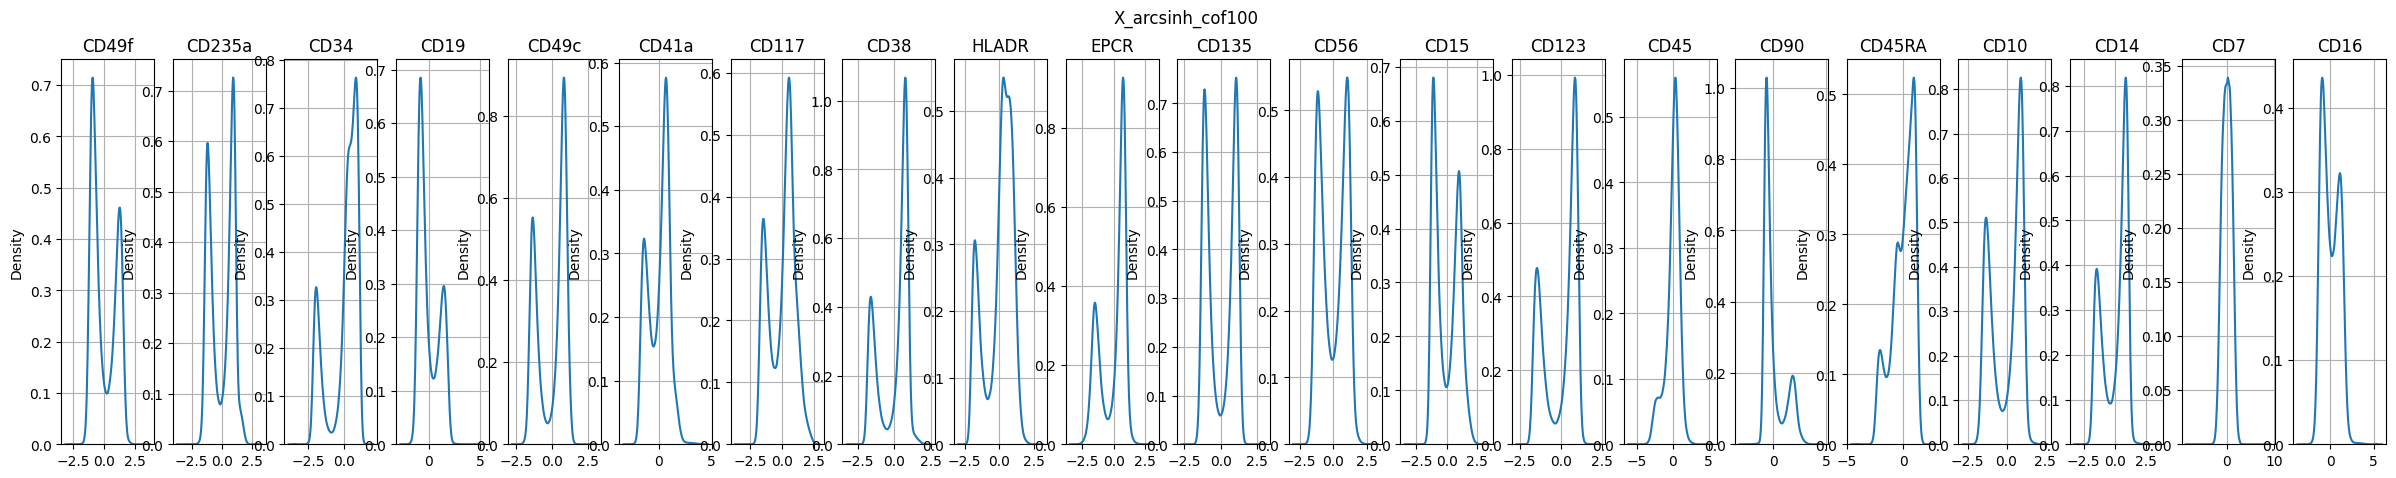

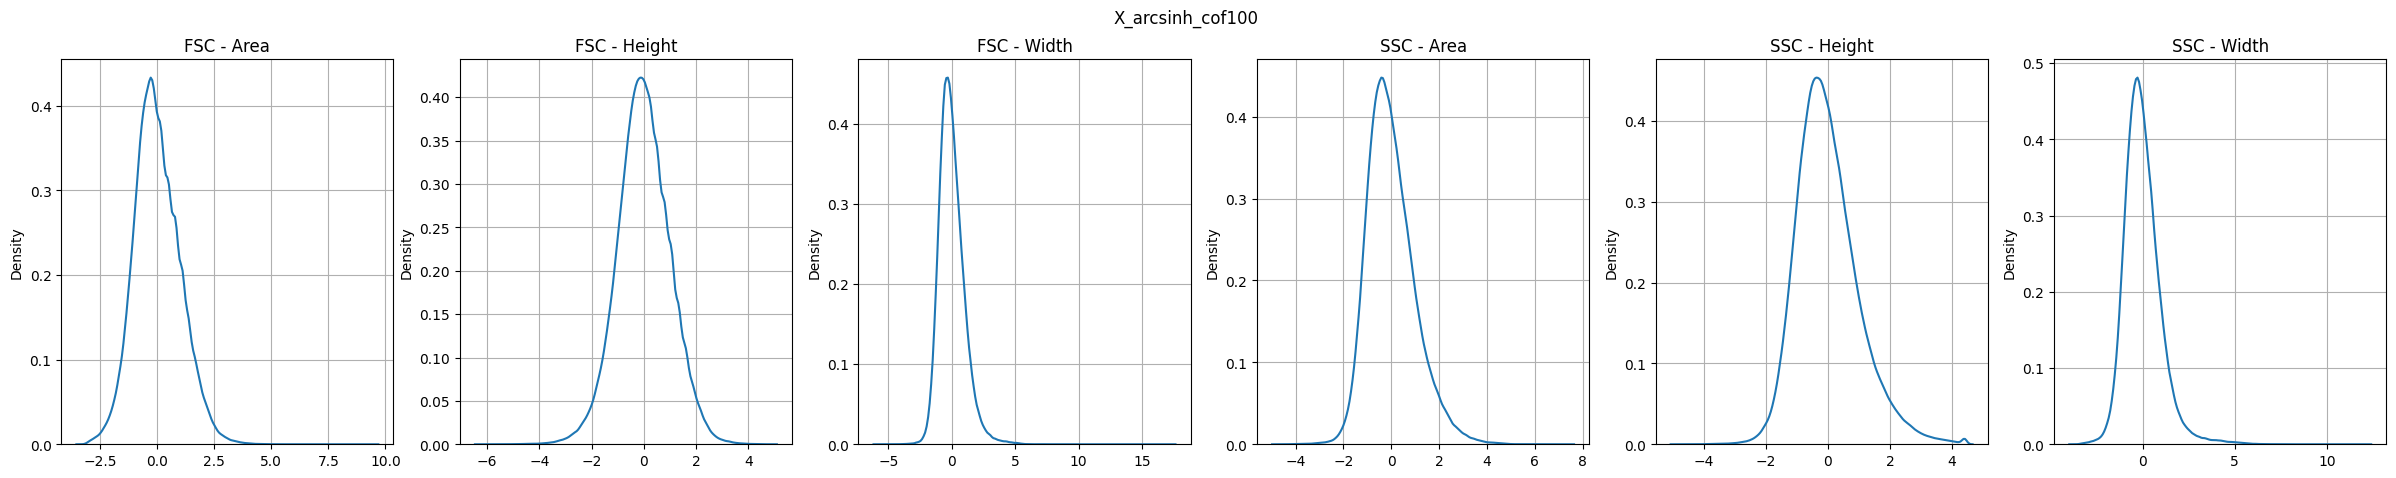

In [ ]:
key_channel = "X_default_cofs"
key_channel = "X_arcsinh_cof100"
X_channel = adata.obsm[key_channel]
X_channel_mean = X_channel.mean(0, keepdims=True)
X_channel_std = X_channel.std(0, keepdims=True)
X_channel = (X_channel - X_channel_mean)/X_channel_std

key_scatter = "X_scatter_log_cof10"
X_scatter = adata.obsm[key_scatter]
X_scatter_mean = X_scatter.mean(0, keepdims=True)
X_scatter_std = X_scatter.std(0, keepdims=True)
X_scatter = (X_scatter - X_scatter_mean)/X_scatter_std

fig, axes = plt.subplots(1, X_channel_mean.shape[-1], figsize=(30, 5))
fig.suptitle(key_channel)
for idx, col in enumerate(adata.var_names):  
    sns.kdeplot(X_channel[:, idx], ax=axes[idx]) 
    axes[idx].set_title(col)
    axes[idx].grid(True)

fig, axes = plt.subplots(1, X_scatter_mean.shape[-1], figsize=(30, 5))
fig.suptitle(key_scatter)
for idx, col in enumerate(SCATTER_COLUMNS):  
    sns.kdeplot(X_scatter[:, idx], ax=axes[idx]) 
    axes[idx].set_title(col)
    axes[idx].grid(True)

repr_key = "X_repr_concat"
X_repr = np.concatenate((X_scatter, X_channel), axis=1)
adata.obsm[repr_key] = X_repr


### Model.

With self.use_guidance=False an unguided flow model will be initialized, thus the settings for the condition encoder will be ignored.
Loss: 1.3082: 100%|██████████| 100000/100000 [03:32<00:00, 471.10it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

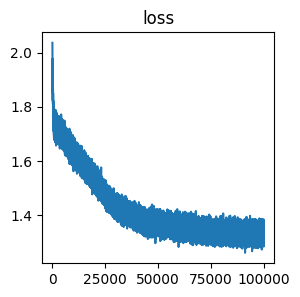

In [33]:
flow_matching = FlowMatching(
    coupling_type="independent",
    generate_from_noise=True,
)

flow_matching.prepare_train_data(
    adata,
    sample_rep=repr_key,
)
cvf_config = NeuralVelocityFieldConfig(
    flow_dim=adata.obsm[repr_key].shape[1],
    encode_state=True,
    state_encoder_output_dim=64,
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=False,
    decoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "dropout_rate": 0.0,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
)
flow_matching.prepare_model(
    cvf_config,
    num_time_steps=100,
)
flow_matching.train(
    num_training_steps=100_000,
)
flow_matching.trainer.plot_training_logs()


### Applying inverse tranformation and visualizing generated samples.

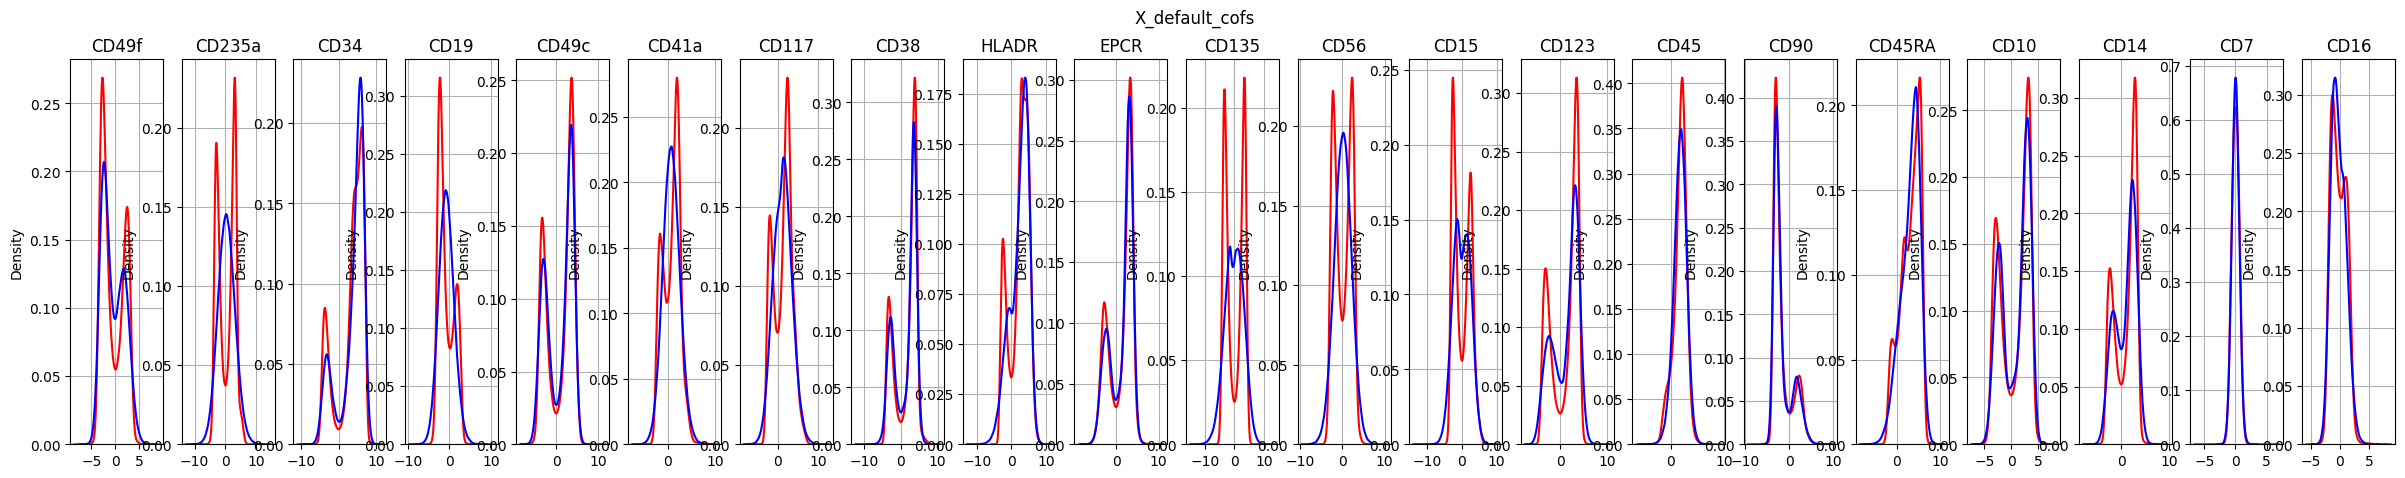

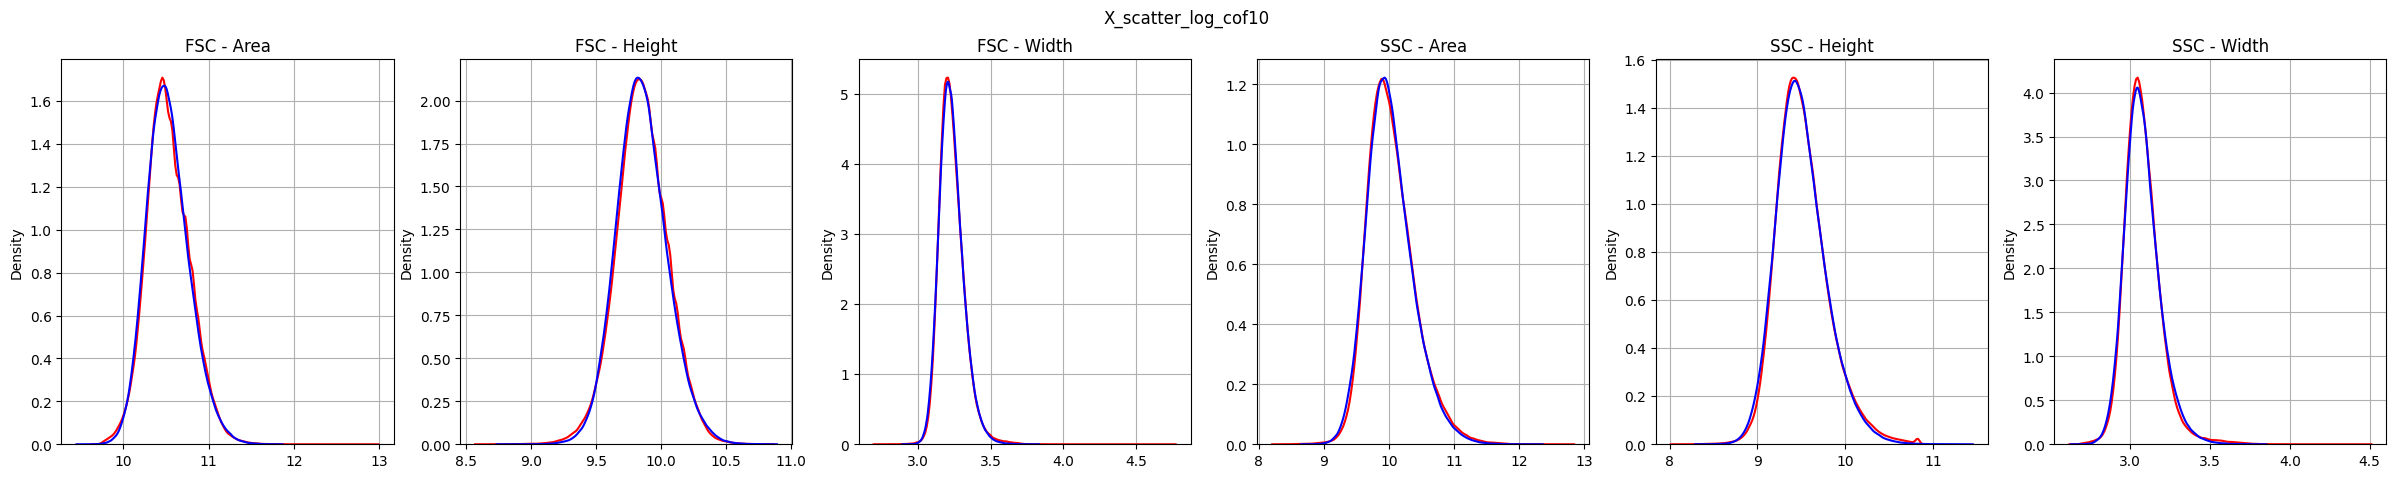

In [ ]:
samples = flow_matching.predict(
    batch={},
    batch_size=400_000,
)
sampled_scatter_feats = samples[:, :-adata.X.shape[1]].detach().cpu().numpy()
sampled_channel_feats = samples[:, -adata.X.shape[1]:].detach().cpu().numpy()
sampled_channel_feats.shape, sampled_scatter_feats.shape 

X_channel_generated = sampled_channel_feats*X_channel_std + X_channel_mean
X_scatter_generated = sampled_scatter_feats*X_scatter_std + X_scatter_mean

fig, axes = plt.subplots(1, X_channel_mean.shape[-1], figsize=(30, 5))
fig.suptitle(key_channel)
for idx, col in enumerate(adata.var_names):  
    sns.kdeplot(adata.obsm[key_channel][:, idx], ax=axes[idx], label="real", color="red") 
    axes[idx].set_title(col)
    axes[idx].grid(True)
      
    sns.kdeplot(X_channel_generated[:, idx], ax=axes[idx], label="generated", color="blue") 
    axes[idx].set_title(col)
    axes[idx].grid(True)

fig, axes = plt.subplots(1, X_scatter_mean.shape[-1], figsize=(30, 5))
fig.suptitle(key_scatter)
for idx, col in enumerate(SCATTER_COLUMNS):  
    sns.kdeplot(adata.obsm[key_scatter][:, idx], ax=axes[idx], label="real", color="red") 
    axes[idx].set_title(col)
    axes[idx].grid(True)
    
    sns.kdeplot(X_scatter_generated[:, idx], ax=axes[idx], label="generated", color="blue") 
    axes[idx].set_title(col)
    axes[idx].grid(True)


### Visualizing the Generated Channel Features.

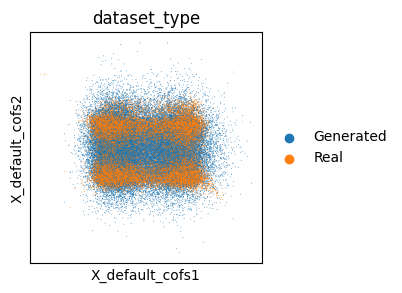

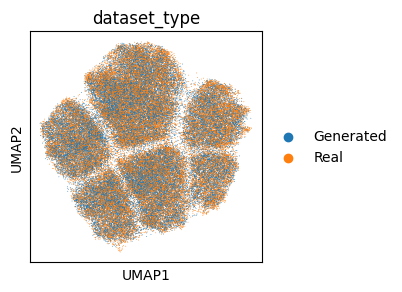

In [29]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_repr", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated


adata_generated = concatenate_adata_and_plot(
    adata,
    X_channel_generated,
    key=key_channel,
)
